In [1]:
import sys
from pathlib import Path
from torchvision import transforms,datasets
from torch.utils.data import Subset,DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score,precision_score,recall_score
sys.path.append(str(Path("..")))
from src.dataset import train_data, train_loader,train_path,train_dataset, val_loader, ood_loader,ood_path
from src.sampler import BalancedBatchSampler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

torch.Size([32, 3, 256, 256])
torch.Size([32])
tensor([3, 3, 1, 2, 5, 7, 3, 2, 5, 5])


In [2]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print(device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:

balanced_sampler = BalancedBatchSampler(
    train_dataset,
    batch_size=32,
    seed=42
)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=balanced_sampler
)

num_classes = len(train_data.classes)

images, labels = next(iter(train_loader)) 
for class_id in range(num_classes):
    count = (labels == class_id).sum().item()
    print(train_data.classes[class_id], count)


ambulance 4
autobus 4
kamyun 4
kamyunet 4
minibus 4
savari 4
taxi 4
vanet 4


In [4]:

class CNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 32 * 32, 256),
            nn.ReLU(),

            nn.Linear(256, num_classes)
        )


    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


num_classes = len(train_data.classes)

model = CNN(num_classes)

model = model.to(device)


criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


num_epochs = 100

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

val_f1_scores = []
val_precision_scores = []
val_recall_scores = []

val_f1_scores_by_class = []
val_precision_scores_by_class = []
val_recall_scores_by_class = []

best_val_f1 = 0.0
best_epoch = 0


for epoch in range(num_epochs):

    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    train_loss = running_train_loss / len(train_loader)

    train_accuracy = train_correct / train_total




    model.eval()

    running_val_loss = 0.0

    val_correct = 0
    val_total = 0

    all_val_labels = []
    all_val_predictions = []


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += loss.item()


            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            all_val_labels.extend(
                labels.cpu().numpy()
            )

            all_val_predictions.extend(
                predicted.cpu().numpy()
            )


    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    val_accuracy = (
        val_correct /
        val_total
    )

    val_f1 = f1_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    val_precision = precision_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    val_recall = recall_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )


    f1_score_by_class = f1_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    precision_by_class = precision_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    recall_by_class = recall_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )




    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_accuracy
    )

    val_losses.append(
        val_loss
    )

    val_accuracies.append(
        val_accuracy
    )

    val_f1_scores.append(
        val_f1
    )

    val_precision_scores.append(
        val_precision
    )

    val_recall_scores.append(
        val_recall
    )

    val_f1_scores_by_class.append(
        f1_score_by_class
    )

    val_precision_scores_by_class.append(
        precision_by_class
    )

    val_recall_scores_by_class.append(
        recall_by_class
    )


    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Precision: {val_precision:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val Macro F1: {val_f1:.4f}"
    )

    print("Precision by each class:")
    print(precision_by_class)

    print("Recall by each class:")
    print(recall_by_class)

    print("F1 Score by each class:")
    print(f1_score_by_class)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "../models/balanced_batch.pth"
        )

        print(
        f"Best model saved! "
        f"Epoch: {best_epoch} | "
        f"Val Macro F1: {best_val_f1:.4f}"
        )





Epoch [1/100] | Train Loss: 1.2371 | Train Acc: 0.6013 | Val Loss: 0.7724 | Val Acc: 0.7521 | Val Precision: 0.7497 | Val Recall: 0.7605 | Val Macro F1: 0.7453
Precision by each class:
[0.75789474 0.70175439 0.61261261 0.66666667 0.90277778 0.88607595
 0.95918367 0.5106383 ]
Recall by each class:
[0.9        0.76923077 0.70833333 0.69090909 0.70652174 0.63063063
 0.87850467 0.8       ]
F1 Score by each class:
[0.82285714 0.73394495 0.65700483 0.67857143 0.79268293 0.73684211
 0.91707317 0.62337662]
Best model saved! Epoch: 1 | Val Macro F1: 0.7453


Epoch [2/100] | Train Loss: 0.3896 | Train Acc: 0.8698 | Val Loss: 0.6895 | Val Acc: 0.7658 | Val Precision: 0.7519 | Val Recall: 0.7435 | Val Macro F1: 0.7456
Precision by each class:
[0.92105263 0.73451327 0.6835443  0.7184466  0.73267327 0.76666667
 0.85840708 0.6       ]
Recall by each class:
[0.875      0.79807692 0.5625     0.67272727 0.80434783 0.82882883
 0.90654206 0.5       ]
F1 Score by each class:
[0.8974359  0.76497696 0.61714286 0.69483568 0.76683938 0.7965368
 0.88181818 0.54545455]
Best model saved! Epoch: 2 | Val Macro F1: 0.7456


Epoch [3/100] | Train Loss: 0.1489 | Train Acc: 0.9502 | Val Loss: 0.7232 | Val Acc: 0.7877 | Val Precision: 0.7839 | Val Recall: 0.7807 | Val Macro F1: 0.7744
Precision by each class:
[0.94736842 0.82727273 0.78378378 0.67175573 0.7755102  0.75833333
 0.95918367 0.54761905]
Recall by each class:
[0.675      0.875      0.60416667 0.8        0.82608696 0.81981982
 0.87850467 0.76666667]
F1 Score by each class:
[0.78832117 0.85046729 0.68235294 0.73029046 0.8        0.78787879
 0.91707317 0.63888889]
Best model saved! Epoch: 3 | Val Macro F1: 0.7744


Epoch [4/100] | Train Loss: 0.0740 | Train Acc: 0.9791 | Val Loss: 0.7317 | Val Acc: 0.8014 | Val Precision: 0.7881 | Val Recall: 0.7918 | Val Macro F1: 0.7876
Precision by each class:
[0.83333333 0.85       0.7173913  0.68217054 0.85897436 0.83486239
 0.96039604 0.56756757]
Recall by each class:
[0.875      0.81730769 0.6875     0.8        0.72826087 0.81981982
 0.90654206 0.7       ]
F1 Score by each class:
[0.85365854 0.83333333 0.70212766 0.73640167 0.78823529 0.82727273
 0.93269231 0.62686567]
Best model saved! Epoch: 4 | Val Macro F1: 0.7876


Epoch [5/100] | Train Loss: 0.0534 | Train Acc: 0.9842 | Val Loss: 0.7518 | Val Acc: 0.7877 | Val Precision: 0.7826 | Val Recall: 0.7713 | Val Macro F1: 0.7732
Precision by each class:
[0.8961039  0.9010989  0.75675676 0.688      0.71028037 0.81904762
 0.82258065 0.66666667]
Recall by each class:
[0.8625     0.78846154 0.58333333 0.78181818 0.82608696 0.77477477
 0.95327103 0.6       ]
F1 Score by each class:
[0.87898089 0.84102564 0.65882353 0.73191489 0.7638191  0.7962963
 0.88311688 0.63157895]


...

Epoch [96/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 1.2922 | Val Acc: 0.8425 | Val Precision: 0.8316 | Val Recall: 0.8305 | Val Macro F1: 0.8300
Precision by each class:
[0.88095238 0.87850467 0.67889908 0.81188119 0.87654321 0.88990826
 0.93577982 0.7       ]
Recall by each class:
[0.925      0.90384615 0.77083333 0.74545455 0.77173913 0.87387387
 0.95327103 0.7       ]
F1 Score by each class:
[0.90243902 0.89099526 0.72195122 0.77725118 0.82080925 0.88181818
 0.94444444 0.7       ]


Epoch [97/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 1.2967 | Val Acc: 0.8411 | Val Precision: 0.8293 | Val Recall: 0.8263 | Val Macro F1: 0.8267
Precision by each class:
[0.88095238 0.87850467 0.67889908 0.81188119 0.87654321 0.88181818
 0.93577982 0.68965517]
Recall by each class:
[0.925      0.90384615 0.77083333 0.74545455 0.77173913 0.87387387
 0.95327103 0.66666667]
F1 Score by each class:
[0.90243902 0.89099526 0.72195122 0.77725118 0.82080925 0.87782805
 0.94444444 0.6779661 ]


Epoch [98/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 1.3008 | Val Acc: 0.8438 | Val Precision: 0.8316 | Val Recall: 0.8288 | Val Macro F1: 0.8293
Precision by each class:
[0.88095238 0.87850467 0.69158879 0.80582524 0.88888889 0.88181818
 0.93577982 0.68965517]
Recall by each class:
[0.925      0.90384615 0.77083333 0.75454545 0.7826087  0.87387387
 0.95327103 0.66666667]
F1 Score by each class:
[0.90243902 0.89099526 0.72906404 0.77934272 0.83236994 0.87782805
 0.94444444 0.6779661 ]


Epoch [99/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 1.3073 | Val Acc: 0.8438 | Val Precision: 0.8316 | Val Recall: 0.8288 | Val Macro F1: 0.8293
Precision by each class:
[0.88095238 0.87850467 0.69158879 0.80582524 0.88888889 0.88181818
 0.93577982 0.68965517]
Recall by each class:
[0.925      0.90384615 0.77083333 0.75454545 0.7826087  0.87387387
 0.95327103 0.66666667]
F1 Score by each class:
[0.90243902 0.89099526 0.72906404 0.77934272 0.83236994 0.87782805
 0.94444444 0.6779661 ]


Epoch [100/100] | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 1.3136 | Val Acc: 0.8438 | Val Precision: 0.8316 | Val Recall: 0.8288 | Val Macro F1: 0.8293
Precision by each class:
[0.88095238 0.87850467 0.69158879 0.80582524 0.88888889 0.88181818
 0.93577982 0.68965517]
Recall by each class:
[0.925      0.90384615 0.77083333 0.75454545 0.7826087  0.87387387
 0.95327103 0.66666667]
F1 Score by each class:
[0.90243902 0.89099526 0.72906404 0.77934272 0.83236994 0.87782805
 0.94444444 0.6779661 ]


In [5]:

num_classes = len(train_data.classes)

model = CNN(num_classes)
model = model.to(device)

model.load_state_dict(
    torch.load("../models/balanced_batch.pth")
)

model = model.to(device)

In [6]:
model.eval()

all_val_labels = []

all_val_predictions = []

all_probabilities = []

all_logits = []

val_correct = 0

val_total = 0


classes = train_data.classes


truck_id = classes.index("kamyun")

truckette_id = classes.index("kamyunet")

van_id = classes.index("vanet")


with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        probabilities = torch.softmax(outputs,dim=1)

        _, predicted = torch.max(outputs,1)
        
        val_total += labels.size(0)

        val_correct += (predicted == labels).sum().item()


        all_val_labels.extend(labels.cpu().numpy())

        all_val_predictions.extend(predicted.cpu().numpy())

        all_probabilities.extend(probabilities.cpu().numpy())

        all_logits.extend(outputs.cpu().numpy())


val_accuracy = val_correct / val_total


val_precision = precision_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_recall = recall_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_f1 = f1_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_precision_by_class = precision_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)


val_recall_by_class = recall_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)


val_f1_by_class = f1_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)
print(f"val Accuracy: {val_accuracy:.4f}")


print(
    f"val Macro Precision: "
    f"{val_precision:.4f}"
)

print(
    f"val Macro Recall: "
    f"{val_recall:.4f}"
)

print(
    f"val Macro F1: "
    f"{val_f1:.4f}"
)


print("val Precision by class:")
print(val_precision_by_class)

print("val Recall by class:")
print(val_recall_by_class)

print("val F1 by class:")
print(val_f1_by_class)

val Accuracy: 0.8479
val Macro Precision: 0.8383
val Macro Recall: 0.8351
val Macro F1: 0.8358
val Precision by class:
[0.88095238 0.9047619  0.68518519 0.80769231 0.87654321 0.88181818
 0.94495413 0.72413793]
val Recall by class:
[0.925      0.91346154 0.77083333 0.76363636 0.77173913 0.87387387
 0.96261682 0.7       ]
val F1 by class:
[0.90243902 0.90909091 0.7254902  0.78504673 0.82080925 0.87782805
 0.9537037  0.71186441]


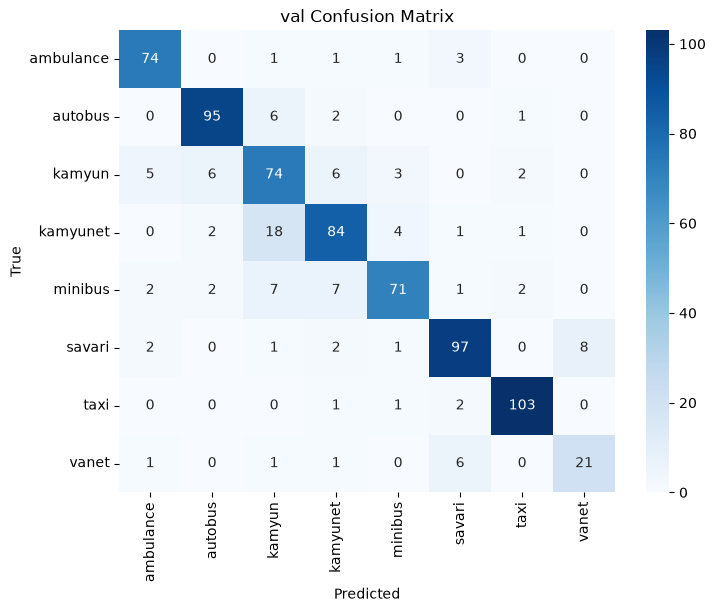

In [7]:
cm = confusion_matrix(
    all_val_labels,
    all_val_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("val Confusion Matrix")

plt.show()

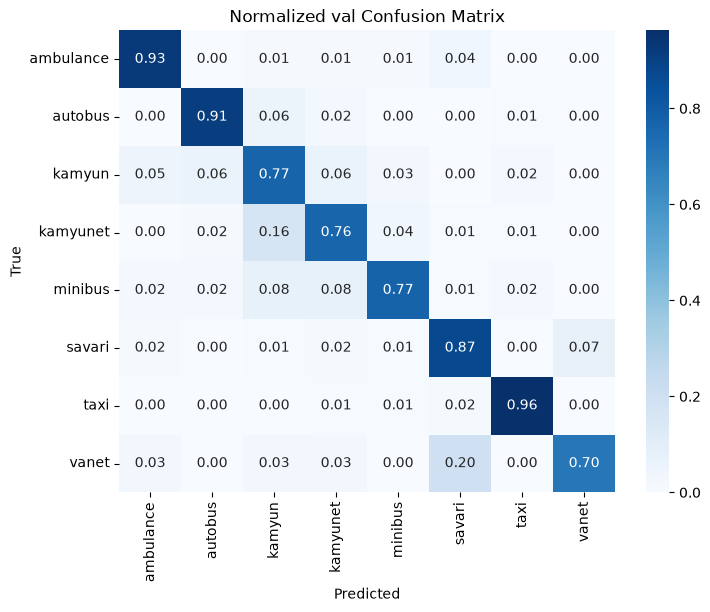

In [8]:
cm_normalized = confusion_matrix(
    all_val_labels,
    all_val_predictions,
    normalize="true"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized val Confusion Matrix")

plt.show()